Which machine learning model performs best on unseen data?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("../../DATA/featured_telco.csv")

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,...,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Internet Service_DSL,Internet Service_Fiber optic,Internet Service_No,Average Charges,CLTV per Month,High Monthly Charge,Loyal Customer
0,0.990658,-0.440327,-0.965608,-0.547115,-1.239504,0.327189,-0.991564,1.408012,1.242875,-1.026988,...,0,0,1,1,0,0,4.006817,4.105072,0,0
1,-1.009430,-0.440327,-0.965608,1.827769,-1.239504,0.327189,-0.991564,-0.917837,-1.028998,-1.026988,...,0,1,0,0,1,0,3.926687,6.004971,1,0
2,-1.009430,-0.440327,-0.965608,1.827769,-0.995040,0.327189,1.116896,-0.917837,-1.028998,1.245441,...,0,1,0,0,1,0,-130.122842,165.510906,1,0
3,-1.009430,-0.440327,1.035617,1.827769,-0.180161,0.327189,1.116896,-0.917837,-1.028998,1.245441,...,0,1,0,0,1,0,0.410465,0.620595,1,0
4,0.990658,-0.440327,-0.965608,1.827769,0.675462,0.327189,1.116896,-0.917837,1.242875,1.245441,...,0,0,0,0,1,0,0.724928,0.473790,1,1


Split Features and Target

In [3]:
X = df.drop(columns=["Churn Label"])

y = df["Churn Label"]

Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote


In [5]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [6]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42)

}

In [7]:
results = []

In [8]:
for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": roc_auc

    })

In [9]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.786780,0.597884,0.604278,0.601064,0.830268
0,Logistic Regression,0.781095,0.571121,0.708556,0.632458,0.842148
3,Gradient Boosting,0.775409,0.563596,0.687166,0.619277,0.842052
1,Decision Tree,0.714996,0.469248,0.550802,0.506765,0.662623


What are the detailed classification results for each model?

Accuracy alone does not fully describe model performance. The Classification Report provides Precision, Recall, and F1-score for each class, helping us better understand prediction quality.

In [10]:
for name, model in models.items():

    print("="*60)

    print(name)

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1033
           1       0.57      0.71      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407

Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1033
           1       0.47      0.55      0.51       374

    accuracy                           0.71      1407
   macro avg       0.65      0.66      0.65      1407
weighted avg       0.73      0.71      0.72      1407

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1033
           1       0.60      0.60      0.60       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79   

 Interpretation


Precision measures prediction correctness.


Recall measures the model's ability to detect churned customers.


F1-score balances Precision and Recall.


The best model should achieve high values across all metrics.

What does the confusion matrix reveal about each model's predictions?

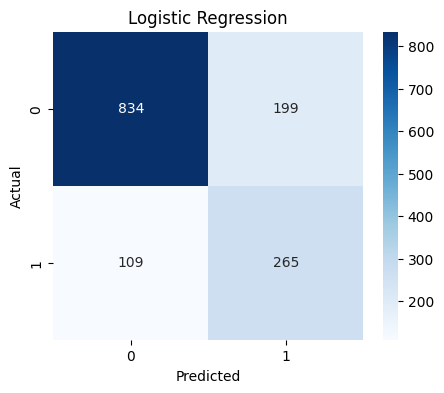

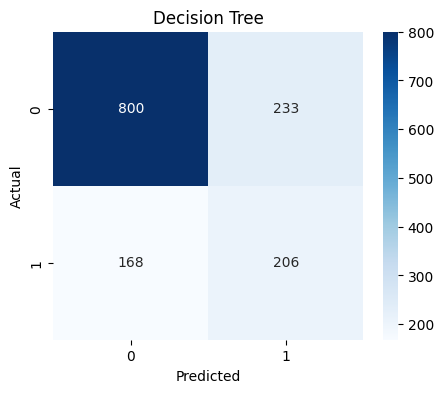

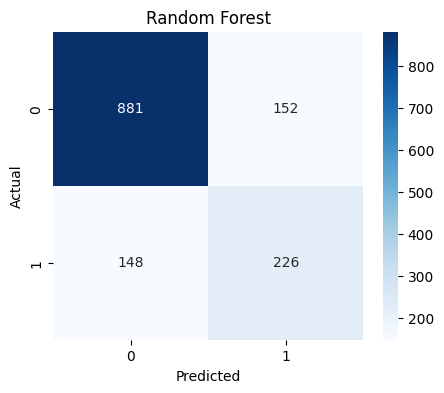

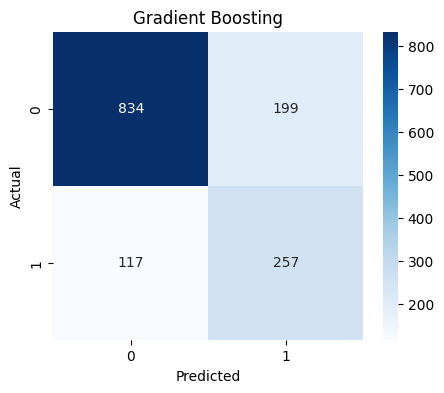

In [11]:
for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

 Interpretation


True Positives indicate correctly predicted churned customers.


True Negatives indicate correctly predicted retained customers.


False Positives and False Negatives represent prediction errors.


Lower error values indicate better model performance.

How well can each model distinguish between churned and retained customers?

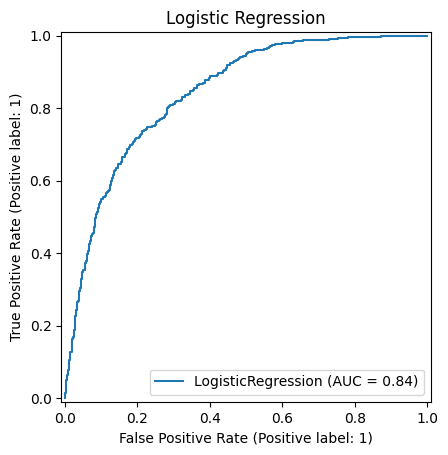

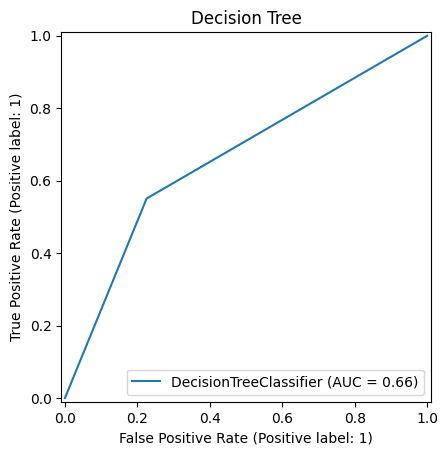

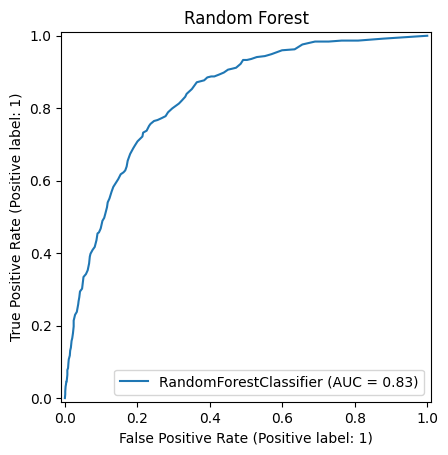

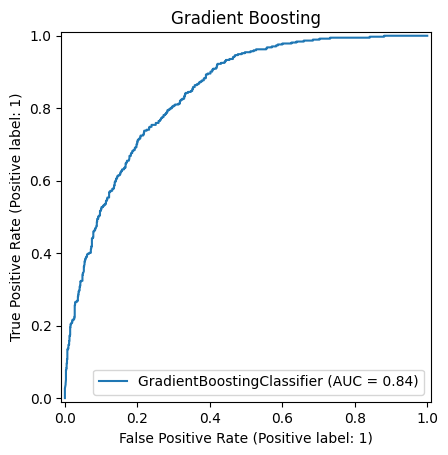

In [12]:
for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test
    )

    plt.title(name)

    plt.show()

 Interpretation

A curve closer to the upper-left corner indicates stronger classification performance.


Higher ROC-AUC values suggest better discrimination between churned and non-churned customers.

 What is the Precision of the model?

 لما الموديل يقول

"العميل هيسيب"

قد إيه بيكون صح؟

 What is the Recall of the model?
هل الموديل قدر يكتشف أغلب العملاء اللى هيسيبوا؟

 What is the F1-score?

 الموديل متوازن بين

Precision

و

Recall.

 What is the ROC-AUC score?

 نقيس قدرة الموديل على التفرقة

بين

Churn

و

Non-Churn.

 What does the Confusion Matrix reveal?

 
 كم عميل توقعه صح.

وكم عميل أخطأ فيه.

Key Insights
Random Forest achieved the highest Accuracy (78.68%) and Precision (59.79%), making it the strongest model in overall prediction accuracy.


Logistic Regression achieved the highest Recall (70.86%), F1-score (63.25%), and ROC-AUC (84.21%), indicating better performance in identifying churned customers.


Gradient Boosting delivered performance very close to Logistic Regression across most evaluation metrics.


Decision Tree showed the weakest overall performance and may not be suitable as the final deployment model.


The final model cannot be selected yet because hyperparameter tuning will be performed in the next task to further improve model performance before the final comparison.